In [1]:
# DEPENDENCIES

import sys
sys.path.insert(0, '..')
from dependencies import *
from constants import *
from paths import *
import helper_functions

In [2]:
# SETUP TO MATCH ANALYSIS

SUBJECTS = helper_functions.get_subjects()
num_testing_subjects = 3
training_subjects = SUBJECTS[:-num_testing_subjects]
testing_subjects = SUBJECTS[len(SUBJECTS)-num_testing_subjects::]

# -----------------------------------------------------------------------------------------------------
# Load backward TRFs for all subjects

trf_types = [
    # Single predictors
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD, False),
]

training_trf_data, n_training_subjects = helper_functions.load_trfs(training_subjects, trf_types, trf_dir=FUGLSANG_TRF_DIR)
#testing_trf_data, n_testing_subjects = helper_functions.load_trfs(testing_subjects, trf_types, trf_dir=FUGLSANG_TRF_DIR)

print('training and validation sets complete')

  ✓ S1
  ✓ S2
  ✓ S3
  ✓ S4
  ✓ S5
  ✓ S6
  ✓ S7
  ✓ S8
  ✓ S9
  ✓ S10
  ✓ S11
  ✓ S12
  ✓ S13
  ✓ S14
  ✓ S15

Loaded: 15 subjects | Skipped: 0 subjects
training and validation sets complete


In [3]:
# MAKE SEPARATE LISTS FOR EACH TRF

# Extract model names
models = []
model_trfs = {}
for type in trf_types:
    models.append(helper_functions.get_trf_model_name(*type))

# -----------------------------------------------------------------------------------------------------
# Loop over all models
for model in models:
    print(f'\nProcessing TRF list for model: {model}')

    # Collect TRFs for all subjects for this model
    training_trf_list = [trf.h_scaled for trf in training_trf_data[model]]
    universal_trf = eelbrain.load.unpickle(FUGLSANG_TRF_DIR / f'universal-{model}.pickle')
    model_trfs[model] = training_trf_list
    model_trfs[f'universal-{model}'] = universal_trf
    print(training_trf_list)

print('\n')
print(models)
print([key for key, value in model_trfs.items()])
print([len(value) for key, value in model_trfs.items()])


Processing TRF list for model: backward_attended_envelope
[<NDVar 'S1_eeg': 64 sensor, 73 time>, <NDVar 'S2_eeg': 64 sensor, 73 time>, <NDVar 'S3_eeg': 64 sensor, 73 time>, <NDVar 'S4_eeg': 64 sensor, 73 time>, <NDVar 'S5_eeg': 64 sensor, 73 time>, <NDVar 'S6_eeg': 64 sensor, 73 time>, <NDVar 'S7_eeg': 64 sensor, 73 time>, <NDVar 'S8_eeg': 64 sensor, 73 time>, <NDVar 'S9_eeg': 64 sensor, 73 time>, <NDVar 'S10_eeg': 64 sensor, 73 time>, <NDVar 'S11_eeg': 64 sensor, 73 time>, <NDVar 'S12_eeg': 64 sensor, 73 time>, <NDVar 'S13_eeg': 64 sensor, 73 time>, <NDVar 'S14_eeg': 64 sensor, 73 time>, <NDVar 'S15_eeg': 64 sensor, 73 time>]

Processing TRF list for model: backward_ignored_envelope
[<NDVar 'S1_eeg': 64 sensor, 73 time>, <NDVar 'S2_eeg': 64 sensor, 73 time>, <NDVar 'S3_eeg': 64 sensor, 73 time>, <NDVar 'S4_eeg': 64 sensor, 73 time>, <NDVar 'S5_eeg': 64 sensor, 73 time>, <NDVar 'S6_eeg': 64 sensor, 73 time>, <NDVar 'S7_eeg': 64 sensor, 73 time>, <NDVar 'S8_eeg': 64 sensor, 73 time>, <

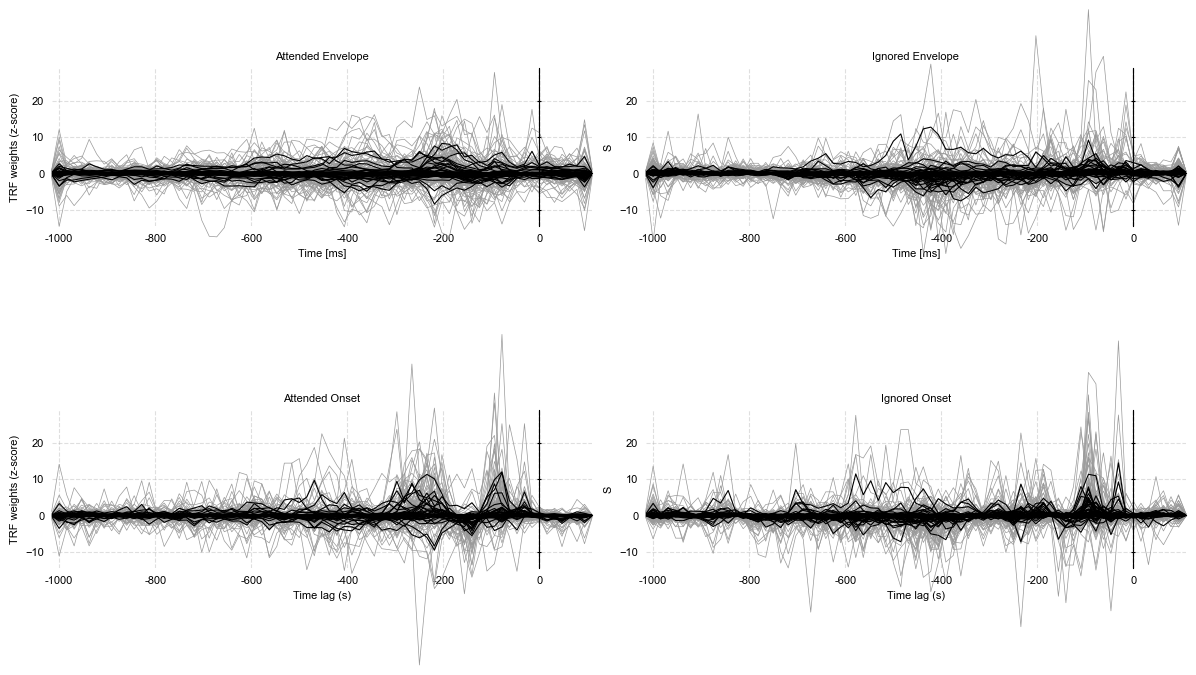

In [4]:
# PLOT

helper_functions.set_plot_style()

# ------------------------------------------------
# Models to plot
# ------------------------------------------------

titles = {
    'backward_attended_envelope': 'Attended Envelope',
    'backward_ignored_envelope': 'Ignored Envelope',
    'backward_attended_envelope_onset': 'Attended Onset',
    'backward_ignored_envelope_onset': 'Ignored Onset'
}

# ------------------------------------------------
# Colors for the different TRFs
# ------------------------------------------------

colors = {
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): 'tab:blue',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): 'tab:orange',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): 'tab:green',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): 'tab:red',
}

# ------------------------------------------------
# Figure
# ------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

# ------------------------------------------------
# Loop over models
# ------------------------------------------------
for idx, model in enumerate(models):

    ax = axes[idx]

    # ----------------------------------------
    # Load individual TRFs
    # ----------------------------------------
    trf_list = model_trfs[model]

    # ----------------------------------------
    # Plot individual TRFs
    # ----------------------------------------
    for trf in trf_list:

        # Average predictors if needed
        if 'predictor' in trf.dims:
            trf_plot = trf.mean('predictor')
        else:
            trf_plot = trf

        # Z-score
        trf_plot = (trf_plot - trf_plot.mean()) / trf_plot.std()

        eelbrain.plot.Butterfly(
            trf_plot,
            axes=ax,
            color='0.6',          # light gray for subjects
            linewidth=0.5,
            frame='t'
        )

    # ----------------------------------------
    # Load and plot universal TRF
    # ----------------------------------------
    trf_univ = model_trfs[f'universal-{model}']

    if 'predictor' in trf_univ.dims:
        trf_univ_plot = trf_univ.mean('predictor')
    else:
        trf_univ_plot = trf_univ

    trf_univ_plot = (trf_univ_plot - trf_univ_plot.mean()) / trf_univ_plot.std()

    eelbrain.plot.Butterfly(
        trf_univ_plot,
        axes=ax,
        color='black',          # strong contrast
        linewidth=0.8,
    )

    # ----------------------------------------
    # SAME vertical scaling trick
    # ----------------------------------------
    y_min = trf_univ_plot.x.min()
    y_max = trf_univ_plot.x.max()
    ax.set_ylim(y_min * 2, y_max * 2)

    # ----------------------------------------
    # Formatting
    # ----------------------------------------
    ax.set_title(titles[model])
    ax.axhline(0, linestyle='--', color='black', linewidth=0.8)
    ax.axvline(0, linestyle='--', color='black', linewidth=0.8)
    ax.grid(True, linestyle='--', alpha=0.4)

# ------------------------------------------------
# Labels
# ------------------------------------------------
axes[2].set_xlabel('Time lag (s)')
axes[3].set_xlabel('Time lag (s)')
axes[0].set_ylabel('TRF weights (z-score)')
axes[2].set_ylabel('TRF weights (z-score)')

plt.tight_layout()
plt.show()



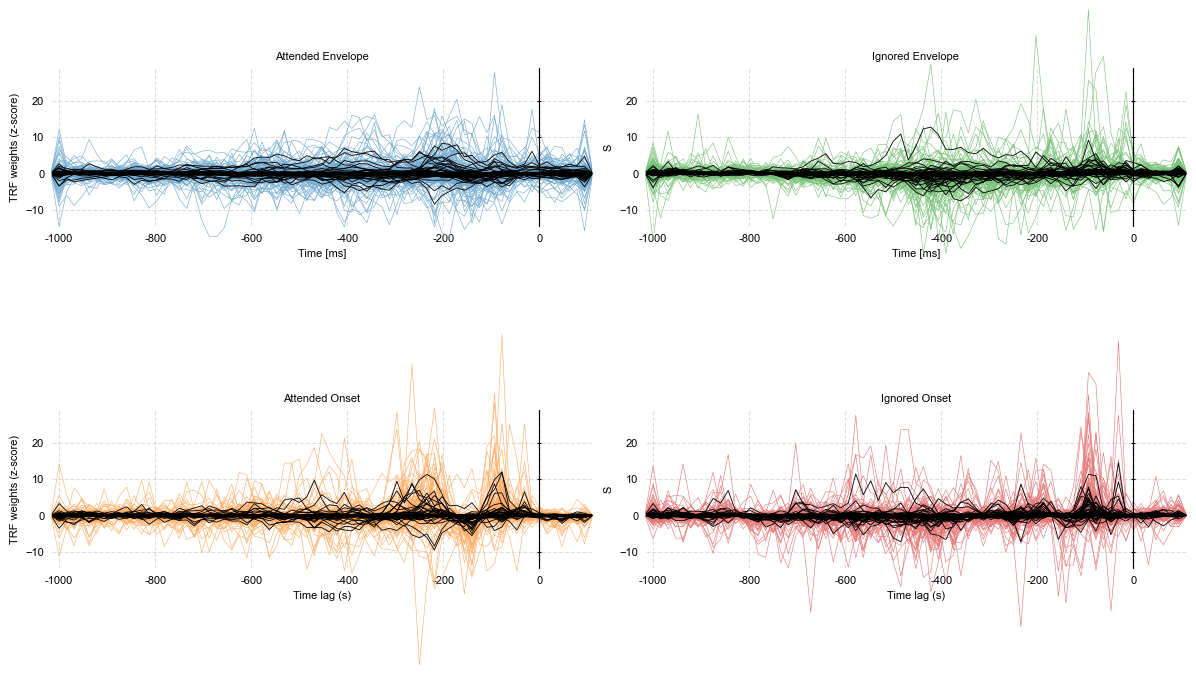

In [5]:
# PLOT

helper_functions.set_plot_style()

# ------------------------------------------------
# Models to plot
# ------------------------------------------------
titles = {
    'backward_attended_envelope': 'Attended Envelope',
    'backward_ignored_envelope': 'Ignored Envelope',
    'backward_attended_envelope_onset': 'Attended Onset',
    'backward_ignored_envelope_onset': 'Ignored Onset'
}

# ------------------------------------------------
# Colors for the different TRFs
# ------------------------------------------------
colors = {
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): 'tab:blue',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): 'tab:orange',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): 'tab:green',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): 'tab:red',
}

# ------------------------------------------------
# Figure
# ------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

# ------------------------------------------------
# Loop over models
# ------------------------------------------------
for idx, model in enumerate(models):

    ax = axes[idx]

    base_color = colors[model]
    light_color = helper_functions.lighten_color(base_color, amount=0.35)

    # ----------------------------------------
    # Load individual TRFs
    # ----------------------------------------
    trf_list = model_trfs[model]

    # ----------------------------------------
    # Plot individual TRFs (faded)
    # ----------------------------------------
    for trf in trf_list:

        if 'predictor' in trf.dims:
            trf_plot = trf.mean('predictor')
        else:
            trf_plot = trf

        # Z-score
        trf_plot = (trf_plot - trf_plot.mean()) / trf_plot.std()

        eelbrain.plot.Butterfly(
            trf_plot,
            axes=ax,
            color=light_color,   # 👈 faded model color
            linewidth=0.4,
            frame='t'
        )

    # ----------------------------------------
    # Load and plot universal TRF (strong)
    # ----------------------------------------
    trf_univ = model_trfs[f'universal-{model}']

    if 'predictor' in trf_univ.dims:
        trf_univ_plot = trf_univ.mean('predictor')
    else:
        trf_univ_plot = trf_univ

    trf_univ_plot = (trf_univ_plot - trf_univ_plot.mean()) / trf_univ_plot.std()

    eelbrain.plot.Butterfly(
        trf_univ_plot,
        axes=ax,
        color='black',   # 👈 strong color
        linewidth=0.6,
    )

    # ----------------------------------------
    # Vertical scaling (same trick)
    # ----------------------------------------
    y_min = trf_univ_plot.x.min()
    y_max = trf_univ_plot.x.max()
    ax.set_ylim(y_min * 2, y_max * 2)

    # ----------------------------------------
    # Formatting
    # ----------------------------------------
    ax.set_title(titles[model])
    ax.axhline(0, linestyle='--', color='black', linewidth=0.8)
    ax.axvline(0, linestyle='--', color='black', linewidth=0.8)
    ax.grid(True, linestyle='--', alpha=0.4)

# ------------------------------------------------
# Labels
# ------------------------------------------------
axes[2].set_xlabel('Time lag (s)')
axes[3].set_xlabel('Time lag (s)')
axes[0].set_ylabel('TRF weights (z-score)')
axes[2].set_ylabel('TRF weights (z-score)')

plt.tight_layout()
plt.show()
